# Aula 5: evolução do IDH por estado

Nesta aula você abre a `Tabela4.csv` (IDHM por Unidade da Federação) e desenha um gráfico de linhas com **matplotlib**.

**O que vamos ver**

1. Abrir um CSV com `;` e vírgula decimal
2. Limpar colunas vazias
3. Passar a tabela do formato largo para o formato longo (`melt`)
4. Plotar a evolução do IDH de cada estado

In [24]:
# No terminal, uma vez: python -m pip install pandas matplotlib
import pandas as pd
import matplotlib.pyplot as plt

In [25]:
path = "Tabela4.csv"

## 1. Abrir o CSV

A primeira linha do arquivo é um título. A segunda linha é o cabeçalho.
O separador é `;`, os números usam vírgula (`0,402`) e o arquivo está em `latin-1` (não UTF-8).

In [26]:
df = pd.read_csv(path, sep=";", skiprows=1, decimal=",", encoding="latin-1")


In [27]:
df = df.dropna(axis=1, how="all")
df.head()

,Sigla,Código,Estado,1991,2000,2010,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,AC,12,Acre,0.402,0.517,0.663,0.705,0.709,0.719,0.719,0.723,0.711,0.731,0.738,0.736,0.702,0.732,0.740,0.754
1,AL,27,Alagoas,0.370,0.471,0.631,0.657,0.653,0.670,0.669,0.680,0.682,0.694,0.693,0.694,0.691,0.722,0.739,0.746
2,AM,13,Amazonas,0.430,0.515,0.674,0.706,0.717,0.720,0.724,0.723,0.743,0.732,0.739,0.725,0.700,0.757,0.764,0.767
3,AP,16,Amapá,0.472,0.577,0.708,0.709,0.735,0.726,0.728,0.732,0.731,0.737,0.732,0.707,0.681,0.743,0.767,0.759
4,BA,29,Bahia,0.386,0.512,0.660,0.684,0.686,0.700,0.708,0.708,0.715,0.714,0.723,0.726,0.698,0.734,0.740,0.759


In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 19 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Sigla   27 non-null     str    
 1   Código  27 non-null     int64  
 2   Estado  27 non-null     str    
 3   1991    27 non-null     float64
 4   2000    27 non-null     float64
 5   2010    27 non-null     float64
 6   2012    27 non-null     float64
 7   2013    27 non-null     float64
 8   2014    27 non-null     float64
 9   2015    27 non-null     float64
 10  2016    27 non-null     float64
 11  2017    27 non-null     float64
 12  2018    27 non-null     float64
 13  2019    27 non-null     float64
 14  2020    27 non-null     float64
 15  2021    27 non-null     float64
 16  2022    27 non-null     float64
 17  2023    27 non-null     float64
 18  2024    27 non-null     float64
dtypes: float64(16), int64(1), str(2)
memory usage: 4.1 KB


## 2. Formato longo

Cada ano está em uma coluna. Para o gráfico, cada linha precisa ser: estado, ano, IDH.

In [29]:
anos = [c for c in df.columns if str(c).isdigit()]
print(anos)

id_vars = [c for c in df.columns if c not in anos]
df_longo = df.melt(
    id_vars=id_vars,
    value_vars=anos,
    var_name="Ano",
    value_name="IDH",
)
df_longo["Ano"] = df_longo["Ano"].astype(int)
df_longo["IDH"] = pd.to_numeric(df_longo["IDH"], errors="coerce")
df_longo.head()

['1991', '2000', '2010', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']


,Sigla,Código,Estado,Ano,IDH
0,AC,12,Acre,1991,0.402
1,AL,27,Alagoas,1991,0.370
2,AM,13,Amazonas,1991,0.430
3,AP,16,Amapá,1991,0.472
4,BA,29,Bahia,1991,0.386


## 3. Gráfico: evolução do IDH por estado

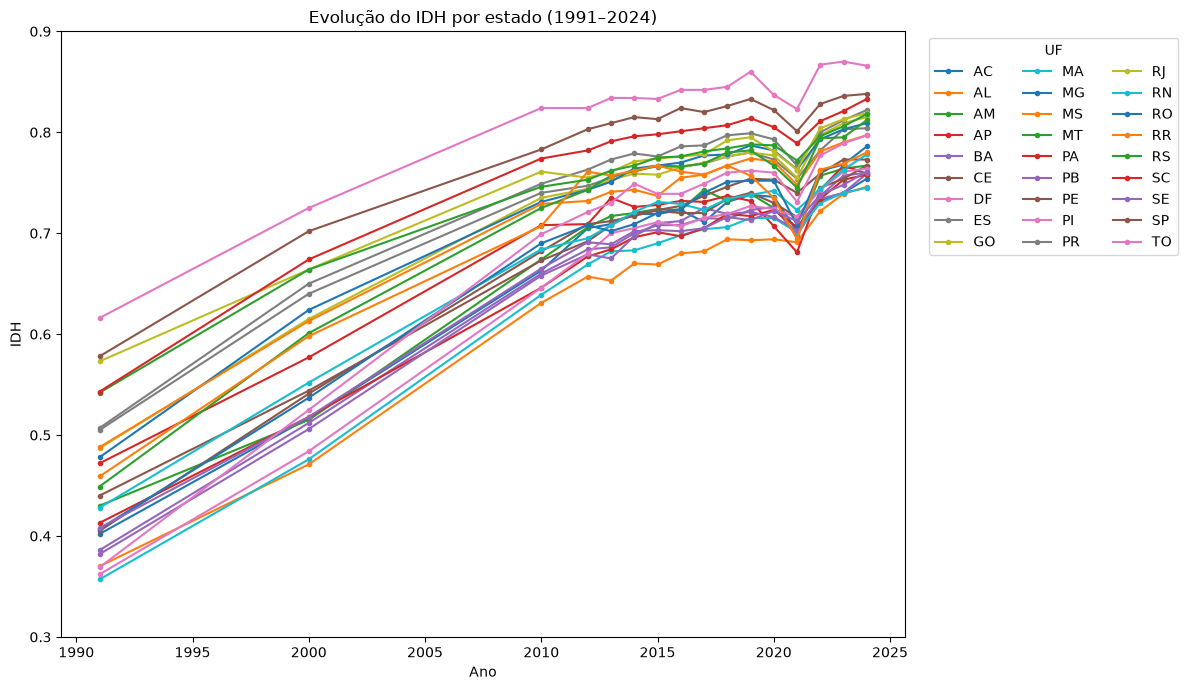

In [30]:
fig, ax = plt.subplots(figsize=(12, 7))

for sigla, grupo in df_longo.groupby("Sigla"):
    grupo = grupo.sort_values("Ano")
    ax.plot(grupo["Ano"], grupo["IDH"], marker="o", markersize=3, linewidth=1.5, label=sigla)

ax.set_title("Evolução do IDH por estado (1991–2024)")
ax.set_xlabel("Ano")
ax.set_ylabel("IDH")
ax.set_ylim(0.3, 0.9)
ax.legend(ncol=3, bbox_to_anchor=(1.02, 1), loc="upper left", title="UF")
fig.tight_layout()
plt.show()

# Atividade

## 3. Ordene os estados por maior IDH em 2024

In [31]:
df_ordenado = df.sort_values(by="2024", ascending=False)
df_ordenado[["Estado", "2024"]].head()

,Estado,2024
6,Distrito Federal,0.866
25,São Paulo,0.838
23,Santa Catarina,0.833
17,Paraná,0.822
18,Rio de Janeiro,0.819


## 4. Qual estado teve a maior melhora de IDH entre os anos de 2024 e 1991?

In [32]:
df["Melhora"] = df["2024"] - df["1991"]
estado_maior_melhora = df.loc[df["Melhora"].idxmax()]

print("Estado com maior melhora:", estado_maior_melhora["Estado"])
print("Aumento de:", round(estado_maior_melhora["Melhora"], 3))

Estado com maior melhora: Tocantins
Aumento de: 0.428


## 5. Existe algum estado em que o IDH piorou?

In [33]:
piorou = df[df["2024"] < df["1991"]]

if piorou.empty:
    print("Nenhum estado piorou seu IDH entre 1991 e 2024.")
else:
    print("Estados que pioraram:")
    display(piorou[["Estado", "1991", "2024"]])

Nenhum estado piorou seu IDH entre 1991 e 2024.


## 5.1 Passar a tabela inicial do formato largo para o formato longo (`melt`)

In [35]:
anos = [col for col in df.columns if str(col).isdigit()]
id_vars = [col for col in df.columns if col not in anos]

df_longo = df.melt(
    id_vars=id_vars,
    value_vars=anos,
    var_name="Ano",
    value_name="IDH"
)

df_longo["Ano"] = df_longo["Ano"].astype(int)
df_longo["IDH"] = pd.to_numeric(df_longo["IDH"], errors="coerce")

df_longo.head()

,Sigla,Código,Estado,Melhora,Ano,IDH
0,AC,12,Acre,0.352,1991,0.402
1,AL,27,Alagoas,0.376,1991,0.370
2,AM,13,Amazonas,0.337,1991,0.430
3,AP,16,Amapá,0.287,1991,0.472
4,BA,29,Bahia,0.373,1991,0.386


## 6. Plote apenas Minas Gerais

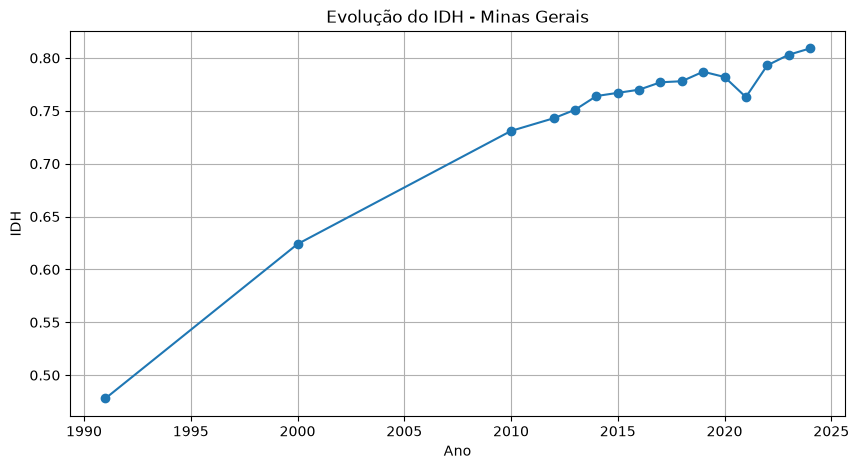

In [21]:
df_mg = df_longo[df_longo["Estado"] == "Minas Gerais"]

plt.figure(figsize=(10, 5))
plt.plot(df_mg["Ano"], df_mg["IDH"], marker="o")
plt.title("Evolução do IDH - Minas Gerais")
plt.xlabel("Ano")
plt.ylabel("IDH")
plt.grid(True)
plt.show()

## 7. Plotar a evolução do IDH de cada estado

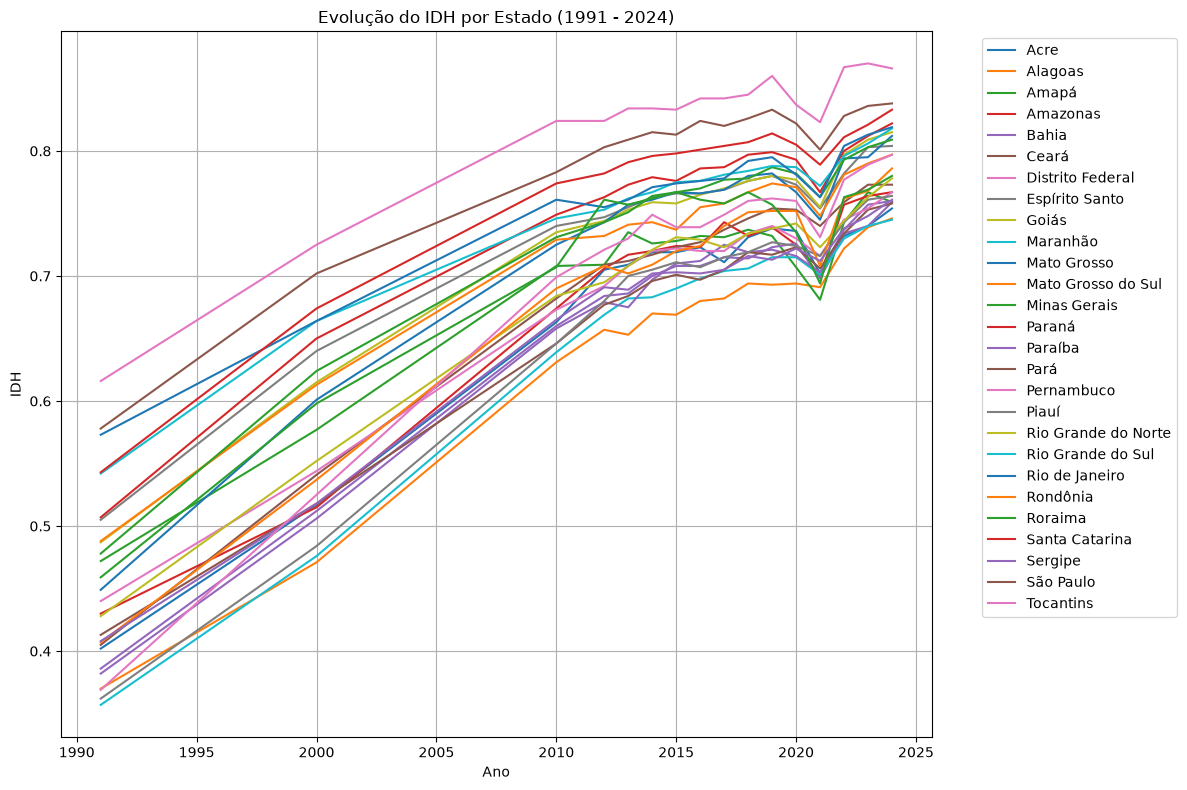

In [22]:
plt.figure(figsize=(12, 8))

for estado, dados in df_longo.groupby("Estado"):
    plt.plot(dados["Ano"], dados["IDH"], label=estado)

plt.title("Evolução do IDH por Estado (1991 - 2024)")
plt.xlabel("Ano")
plt.ylabel("IDH")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.grid(True)
plt.tight_layout()
plt.show()